In [2]:
# Goal: Modeling (Feature Section, Train/Test Split, Model Training, Evaluation)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

path = "../data/processed/cleaned_world_cup_matches.csv"
df = pd.read_csv(path)

#Target variable( Won/Loss )
y = df["team1_result"]

# All the leaky columns directly related to goals
leaky_columns = [ 
    'number of goals team1', 'number of goals team2',
    'goal inside the penalty area team1', 'goal outside the penalty area team1',
    'assists team1', 'penalties scored team1', 'conceded team2',
    'goal inside the penalty area team2', 'goal outside the penalty area team2',
    'assists team2', 'penalties scored team2', 'conceded team1'
]

# Grab only numberical data and drop leaky columns
numerical_df = df.select_dtypes(include=['number'])
X = numerical_df.drop(columns=[col for col in leaky_columns if col in numerical_df.columns])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (64, 70)
y shape: (64,)


In [10]:
# Training the model


#Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random forest algorithm
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

accuracy = rf_model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 61.54% accuracy which may sound bad but if you were to randomly guess
# the accuracy would only be 33%

Model Accuracy: 61.54%


In [ ]:
# Feature Importance ( Find what features it relied on the most )

# Extract the importances
importances = rf_model.feature_importances_

# Match scores to column names
importance_df = pd.DataFrame({
    'Statistic': X.columns,
    'Importance': importances
})

top_10_features = importance_df.sort_values(by="Importance", ascending=False).head(10)
print(top_10_features)

                                  Statistic  Importance
4                  on target attempts team1    0.037843
59                            corners team2    0.033595
27        inbetween offers to receive team2    0.033326
66                   forced turnovers team1    0.031065
60                         free kicks team1    0.027263
9   attempts inside the penalty area  team2    0.024292
5                  on target attempts team2    0.023443
17                    central channel team2    0.022021
58                            corners team1    0.021368
34               completed line breaksteam1    0.021125


C:\Users\bigor\AppData\Local\Temp\ipykernel_10176\2433338.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x="Importance", y="Statistic", palette="viridis")


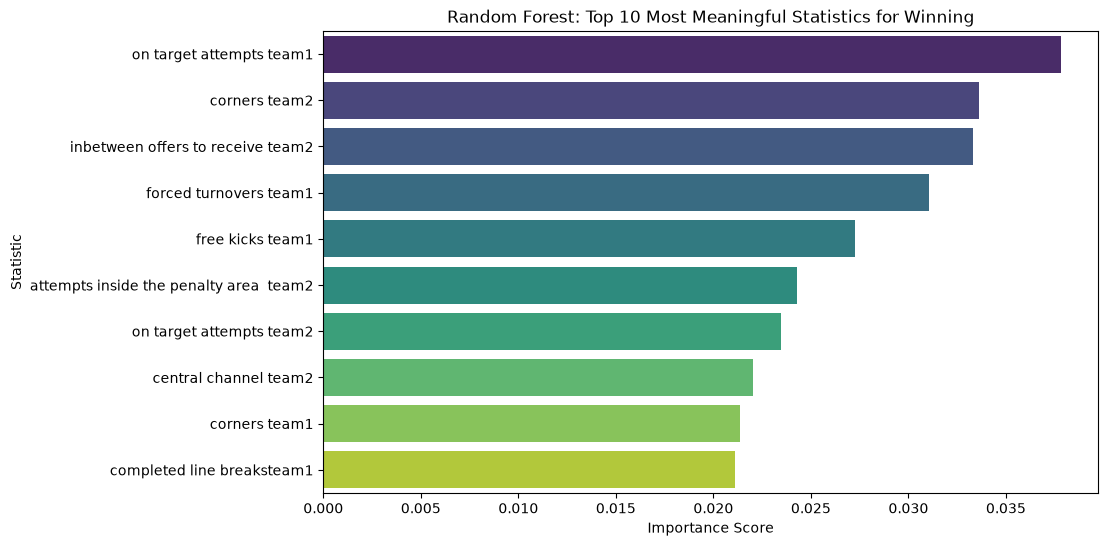

In [12]:
# Plot the data
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x="Importance", y="Statistic", palette="viridis")
plt.title("Random Forest: Top 10 Most Meaningful Statistics for Winning")
plt.xlabel("Importance Score")
plt.ylabel("Statistic")
plt.savefig('../visuals/ml_feature_importance.png', bbox_inches='tight')
plt.show()